In [2]:
# Imports
from dataclasses import dataclass
import random
import numpy as np
from deap import base, creator, tools, algorithms
import csv
from deap.tools import cxOnePoint, cxTwoPoints
import time
import math
import copy

random.seed(42)

In [3]:
# A gene contains 2 attributes : the food item's name and the number of servings of this item
@dataclass
class Gene:
    food_item_name: str
    serving: int

In [4]:
# We make a list representing all the meals we have in 1 chromosome
Meals = ["Breakfast", "Snack 1", "Lunch", "Snack 2", "Dinner"]
# We make a list representing all the food groups we have in 1 meal
Food_Groups = ["Vegetables", "Fruits", "Grains", "Protein", "Dairy", "Fats and Oils"]

In [5]:
# Load dataset
def load_food_data(csv_path):
    food_data = {}
    meal_flags = {}

    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)

        for row in reader:
            group = row['Category']
            food = row['Food Item']

            if group not in food_data:
                food_data[group] = {}

            # Safely convert numeric columns, use 0 if empty
            def safe_float(x):
                try:
                    return float(x)
                except (ValueError, TypeError):
                    return 0.0

            food_data[group][food] = {
                'p': safe_float(row['Protein (g)']),
                'f': safe_float(row['Fats (g)']),
                'c': safe_float(row['Carbohydrates (g)']),
                'cal': safe_float(row['Calories (kcal)']),
                'pref': safe_float(row['User Preference'])
            }

            # Safely convert meal flags (0 if empty)
            def safe_int(x):
                try:
                    return int(x)
                except (ValueError, TypeError):
                    return 0

            meal_flags[food] = {
                'Breakfast': safe_int(row['Breakfast']),
                'Snack 1': safe_int(row['Snack 1']),
                'Lunch': safe_int(row['Lunch']),
                'Snack 2': safe_int(row['Snack 2']),
                'Dinner': safe_int(row['Dinner'])
            }

    return food_data, meal_flags


FOOD_DATA, MEAL_FLAGS = load_food_data("Processed_Bahrain_Food_Dataset.csv")

In [6]:
# Dictionary that contains all the saudi guideline's servings
SERVING_GUIDELINES_BY_KCAL = {
    1200: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 0},
        "Snack 2": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1300: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1400: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1500: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1600: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1700: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1800: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    },

    1900: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    },

    2000: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 2, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 2, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    2200: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 2, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 2, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    }
}

In [7]:
# DEAP Configuration
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()


# Initialize Population
def create_individual():
    # Initializes 30 genes following 1600 kcal
    genes = []
    for meal in Meals:
        for group in Food_Groups:
            # Get the fixed serving count for this meal/group
            serving_count = SERVING_GUIDELINES_BY_KCAL[TARGET_KCAL][meal][group]

            # Filter foods allowed for this meal
            allowed_foods = [
                food for food in FOOD_DATA[group].keys() if MEAL_FLAGS[food][meal] == 1
            ]
            if not allowed_foods:
                allowed_foods = list(FOOD_DATA[group].keys())  # fallback

            # Randomly select food from allowed foods
            food_name = random.choice(allowed_foods)

            # Create gene with guideline serving count
            genes.append(Gene(food_item_name=food_name, serving=serving_count))

    return creator.Individual(genes)


toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


# Fitness Function
def evaluate_meal_plan(individual):
    total_p = 0.0  # Protein grams
    total_f = 0.0  # Fat grams
    total_c = 0.0  # Carbohydrates grams
    total_cal = 0.0  # Total Calories
    total_pref = 0.0  # Total user preference

    # Sum up all grams and calories based on food item and serving count
    for gene in individual:
        group_name = None
        # Find which group this food belongs to
        for group, foods in FOOD_DATA.items():
            if gene.food_item_name in foods:
                group_name = group
                break

        if group_name:
            stats = FOOD_DATA[group_name][gene.food_item_name]
            total_p += stats['p'] * gene.serving
            total_f += stats['f'] * gene.serving
            total_c += stats['c'] * gene.serving
            total_cal += stats['cal'] * gene.serving
            if gene.serving > 0:
                total_pref += stats['pref']
    # Calculate actual macro percentages (p_c, p_p, p_f)
    g_total = total_p + total_f + total_c
    if g_total == 0: return 0,  # Avoid division by zero

    p_p = total_p / g_total
    p_f = total_f / g_total
    p_c = total_c / g_total

    # Target Ratios (The AMDR values)
    r_p, r_f, r_c = 0.20, 0.25, 0.55

    # Objective function: J_macro (Squared Error)
    j_macro = (p_c - r_c) ** 2 + (p_p - r_p) ** 2 + (p_f - r_f) ** 2

    # Total calorie constraint (J_cal)
    r = (total_cal - TARGET_KCAL) / TARGET_KCAL
    j_cal = min(1, r ** 2)

    # Variety constraint (J_var)
    N = sum(1 for gene in individual if
            gene.serving > 0)  # total number of food items in the chromosome (N is taken from the report)
    # count food appearance
    food_appearance = {}
    for gene in individual:
        if gene.serving > 0:
            food_appearance[gene.food_item_name] = food_appearance.get(gene.food_item_name, 0) + 1
    # Calculate the penalty for variety
    j_var = 0
    for food_name, count in food_appearance.items():
        # we penalize if the food item appears more than once
        if count > 1:
            j_var += max(0, count - 1) ** 2
    # Normalize the penalty
    j_var = j_var / ((N - 1) ** 2)

    # User preference constraint (J_pref)
    j_pref = total_pref / N

    # Calculate the score
    w_macro, w_cal, w_var, w_pref = WEIGHTS # WEIGHTS can change
    score = w_macro * j_macro + w_var * j_var + w_cal * j_cal + w_pref * j_pref

    # store the penalties to print later
    individual.j_var = j_var
    individual.j_macro = j_macro
    individual.j_cal = j_cal
    individual.j_pref = j_pref

    # We want to minimize score, so we return a fitness that increases as score decreases
    return 1 / (1 + score),


# Crossover
def one_cx_meal_plan(parent1, parent2):
    GROUPS = 6
    MEALS = 5

    m1 = random.randrange(1, MEALS)
    cut = m1 * GROUPS
    parent1[cut:], parent2[cut:] = parent2[cut:], parent1[cut:]
    return parent1, parent2


def two_cx_meal_plan(parent1, parent2):
    GROUPS = 6
    MEALS = 5

    # Choose 2 meal cut points
    m1, m2 = sorted(random.sample(range(1, MEALS), 2))
    cut1, cut2 = m1 * GROUPS, m2 * GROUPS

    # Swap full meals
    parent1[cut1:cut2], parent2[cut1:cut2] = parent2[cut1:cut2], parent1[cut1:cut2]

    return parent1, parent2


# Mutation
def mutate_meal_plan(individual):
    mutations_done = 0
    all_indices = list(range(len(individual)))  # List of all possible indices in the chromosome
    random.shuffle(all_indices)  # Shuffle to pick randomly without repeating the same one

    for i in all_indices:
        if mutations_done >= 2:
            break  # Stop once we have mutated 2 genes

        # Check if the serving size is not zero
        if individual[i].serving > 0:
            # Find which group it belongs to (Vegetables, Grains, ...)
            group_name = Food_Groups[i % 6]
            # What meal it belongs to (Breakfast, Snack 1,...)
            meal = Meals[i // 6]

            # Check compatibility
            allowed_foods = [
                food for food in FOOD_DATA[group_name].keys() if MEAL_FLAGS[food][meal] == 1
            ]
            if allowed_foods:
                # Pick a new food name from food group dictionary, but the serving remains the same
                individual[i].food_item_name = random.choice(allowed_foods)
                mutations_done += 1
    return individual,


toolbox.register("evaluate", evaluate_meal_plan)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", cxOnePoint)  # one-point crossover
toolbox.register("mutate", mutate_meal_plan)

In [8]:
# GA Execution Loop
def run_simulation(target_kcal, pop_size, cxpb, mutpb, patience):
    global TARGET_KCAL, WEIGHTS
    TARGET_KCAL = target_kcal  # tells create_individual which guideline to use

    pop = toolbox.population(n=pop_size)

    hof = tools.HallOfFame(1)  # Keeps the absolute best found across all generations

    mu = len(pop)  # Number of individuals to select for the next generation
    lambd = 100  # Number of children to produce in each generation
    MAX_GEN = 300  #max num no more
    PATIENCE = patience
    EPS = 1e-6  #small new update ignor
    best_so_far = None
    stagnant = 0
    # Statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)
    for gen in range(MAX_GEN):

        # run ONE generation
        algorithms.eaMuPlusLambda(
            pop, toolbox,
            mu=mu,
            lambda_=lambd,
            cxpb=cxpb,
            mutpb=mutpb,
            ngen=1,
            stats=stats,
            halloffame=hof,
            verbose=False
        )
        hof.update(pop)

        current_best = hof[0].fitness.values[0]

        if best_so_far is None or current_best > best_so_far + EPS:
            best_so_far = current_best
            stagnant = 0
        else:
            stagnant += 1

        if stagnant >= PATIENCE:
            #print(f"\nEarly stopping at generation {gen + 1} (no improvement for {PATIENCE} gens)")
            break
    #print(f"Final Gen {gen + 1} | best={current_best:.8f} | stagnant={stagnant}/{PATIENCE}")
    #print("-" * 50)

    return hof[0].fitness.values[0], gen + 1

In [9]:
# Random Search
def run_random_search(time_budget):
    start_time = time.time()

    best_individual = None
    best_fitness = -float("inf")
    trials = 0

    while (time.time() - start_time) < time_budget:
        ind = create_individual()
        fitness = evaluate_meal_plan(ind)[0]
        trials += 1

        if fitness > best_fitness:
            best_fitness = fitness
            best_individual = ind
    end_time = time.time()
    total_time = end_time - start_time

    return best_individual, best_fitness, trials, total_time

In [10]:
#Local Search
def run_local_search(toolbox, pop_size, time_budget):

    start_time = time.time()

    # 1. Generate initial population
    pop = toolbox.population(n=pop_size)

    # 2. Evaluate population
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    # 3. Pick A random solution from initial population
    current = toolbox.clone(random.choice(pop))

    best = toolbox.clone(current)
    best_fitness = current.fitness.values[0]

    trials = 0

    # 4. Local search loop
    while (time.time() - start_time) < time_budget:

        neighbor = toolbox.clone(current)
        neighbor, = mutate_meal_plan(neighbor)

        neighbor.fitness.values = toolbox.evaluate(neighbor)
        trials += 1

        if neighbor.fitness.values[0] > current.fitness.values[0]:
            best = toolbox.clone(neighbor)
            best_fitness = neighbor.fitness.values[0]
            current = neighbor


    return best, best_fitness, trials

In [11]:
#Simulated annealing
def fitness_to_cost(fitness):
    return (1 / fitness) - 1


def get_neighbor(individual):
    new_individual = copy.deepcopy(individual)

    mutations_done = 0
    all_indices = list(range(len(new_individual)))
    random.shuffle(all_indices)

    for i in all_indices:
        if mutations_done >= 2:
            break

        if new_individual[i].serving > 0:
            group_name = Food_Groups[i % 6]
            meal = Meals[i // 6]

            allowed_foods = [
                food for food in FOOD_DATA[group_name].keys()
                if MEAL_FLAGS[food][meal] == 1
            ]
            if allowed_foods:
                new_individual[i].food_item_name = random.choice(allowed_foods)
                mutations_done += 1

    return new_individual


def run_simulated_annealing(toolbox, pop_size,
                            cooling_rate=0.98,
                            iterations_per_temp=200,
                            time_limit=None):

    # Generate population
    current = toolbox.individual()
    current_fitness = evaluate_meal_plan(current)[0]
    current_cost = fitness_to_cost(current_fitness)


    best = copy.deepcopy(current)
    best_fitness = current_fitness

    T = 1.0
    min_temp=0.001
    total_iterations = 0
    start_time = time.time()


    while T > min_temp:
        if time_limit and (time.time() - start_time) >= time_limit:
            break
        for _ in range(iterations_per_temp):

            new = get_neighbor(current)
            new_fitness = evaluate_meal_plan(new)[0]
            new_cost = fitness_to_cost(new_fitness)

            delta = new_cost - current_cost

            if delta <= 0 or random.random() < math.exp(-delta / T):
                current = new
                current_fitness = new_fitness
                current_cost = new_cost

            if current_fitness > best_fitness:
                best = copy.deepcopy(current)
                best_fitness = current_fitness

            total_iterations += 1

        T *= cooling_rate

    return best, best_fitness, total_iterations

In [12]:
def print_meal_plan(individual):
    total_p = total_f = total_c = total_cal = 0.0

    #print(f"\n{'MEAL':<12} | {'GROUP':<14} | {'FOOD ITEM':<25} | {'SERV.':<6} | {'P (g)':<6} | {'F (g)':<6} | {'C (g)':<6} | {'CALS':<6} | {'PREF':<6}")
    #print("-" * 100)

    for i, gene in enumerate(individual):
        meal = Meals[i // 6]
        group = Food_Groups[i % 6]
        stats = FOOD_DATA[group][gene.food_item_name]
        p = stats['p'] * gene.serving
        f = stats['f'] * gene.serving
        c = stats['c'] * gene.serving
        cal = stats['cal'] * gene.serving
        pref = stats['pref'] if gene.serving > 0 else 0
        total_p += p
        total_f += f
        total_c += c
        total_cal += cal
        #print(f"{meal:<12} | {group:<14} | {gene.food_item_name:<25} | {gene.serving:<6} | {p:<6.1f} |{f:<6.1f} | {c:<6.1f} | {cal:<6.1f} | {pref:<6.2f}")

    g_total = total_p + total_f + total_c
    p_p = (total_p / g_total) * 100
    p_f = (total_f / g_total) * 100
    p_c = (total_c / g_total) * 100
    variety = (1 - individual.j_var) * 100
    calories = (total_cal / TARGET_KCAL) * 100
    preference_score = (1 - individual.j_pref) * 100

    print("\n" + "=" * 40)
    print("       DAILY NUTRITION SUMMARY")
    print("=" * 40)
    print(f"Total Energy:   {total_cal:.1f} kcal")
    print(f"Total Weight:   {g_total:.1f} g (Macro Grams)")
    print("-" * 40)
    print(f"Nutrient        | Actual % | Target %")
    print(f"Carbs (c)       | {p_c:>7.1f}% | 55.0%")
    print(f"Protein (p)     | {p_p:>7.1f}% | 20.0%")
    print(f"Fats (f)        | {p_f:>7.1f}% | 25.0%")
    print(f"Meal variety    | {variety:>7.1f}% | 100%")
    print(f"Meal calorie    | {calories:>7.1f}% | 100%")
    print(f"User preference | {preference_score:>7.1f}% | 100%")
    print("=" * 40)

In [12]:
target_cals = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
WEIGHTS = (0.35, 0.35, 0.20, 0.10)

# GA best parameters
pop_size = 95
cxpb = 0.55
mutpb = 0.17
patience = 50

weight_configs = [ # loop over different weights
    (0.35, 0.35, 0.20, 0.10),
    (0.25, 0.25, 0.25, 0.25),
]

all_results = {}

# Execute 10 runs for each weight config in target cal
for weights in weight_configs:
    WEIGHTS = weights
    all_results[weights] = {}

    print(f"\n===== Weights {weights} =====")


    for target in target_cals:
        ga_fitness_list = []
        rs_fitness_list = []
        ls_fitness_list = []
        sa_fitness_list = []
        runtime_list = []

        print(f"\n===== Target {target} =====")
        print(f"{'Run':<5} {'StopGen(GA)':<13} {'Trials(RS)':<13} {'Trials(LS)':<13} {'Iter(SA)':<12} {'GA Fit':<12} {'RS Fit':<12} {'LS Fit':<12} {'SA Fit':<12} {'Time(s)':<12}")

        for run in range(1, 11):
            start_time = time.time()

            ga_fitness, stopping_gen = run_simulation(
                target,
                pop_size=pop_size,
                cxpb=cxpb,
                mutpb=mutpb,
                patience=patience
            )

            end_time = time.time()
            runtime_ga = end_time - start_time

            ga_fitness_list.append(ga_fitness)
            runtime_list.append(runtime_ga)

            # RS execution
            rs_best, rs_fitness, rs_trials, rs_time = run_random_search(runtime_ga)
            rs_fitness_list.append(rs_fitness)

            # Local Search execution
            start_time_ls = time.time()
            ls_best, ls_fitness, ls_trials = run_local_search(toolbox, pop_size, runtime_ga)
            end_time_ls = time.time()
            runtime_ls = end_time_ls - start_time_ls
            ls_fitness_list.append(ls_fitness)

            # SA execution
            start_time_sa = time.time()
            sa_best, sa_fitness, sa_iters = run_simulated_annealing(
                toolbox, pop_size, time_limit=runtime_ga
            )
            end_sa = time.time()
            runtime_sa = end_sa - start_time_sa
            sa_fitness_list.append(sa_fitness)

            print(f"{run:<5} {stopping_gen:<13} {rs_trials:<13} {ls_trials:<13} {sa_iters:<12} "
                f"{ga_fitness:<12.6f} {rs_fitness:<12.6f} {ls_fitness:<12.6f} {sa_fitness:<12.6f} "
                f"{runtime_ga:<12.4f}")

        all_results[weights][target] = {
            'ga': ga_fitness_list,
            'rs': rs_fitness_list,
            'ls': ls_fitness_list,
            'sa': sa_fitness_list,
        }

        # Stats
        avg_ga_fitness = np.mean(ga_fitness_list)
        max_ga_fitness = np.max(ga_fitness_list)
        min_ga_fitness = np.min(ga_fitness_list)
        std_ga_fitness = np.std(ga_fitness_list)

        avg_rs_fitness = np.mean(rs_fitness_list)
        max_rs_fitness = np.max(rs_fitness_list)
        min_rs_fitness = np.min(rs_fitness_list)
        std_rs_fitness = np.std(rs_fitness_list)

        avg_ls_fitness = np.mean(ls_fitness_list)
        max_ls_fitness = np.max(ls_fitness_list)
        min_ls_fitness = np.min(ls_fitness_list)
        std_ls_fitness = np.std(ls_fitness_list)

        avg_sa_fitness = np.mean(sa_fitness_list)
        max_sa_fitness = np.max(sa_fitness_list)
        min_sa_fitness = np.min(sa_fitness_list)
        std_sa_fitness = np.std(sa_fitness_list)

        avg_runtime_ga = np.mean(runtime_list)

        print("-" * 50)
        print(f"{'GA Avg fitness:':<25} {avg_ga_fitness:<12.6f}")
        print(f"{'GA Maximum fitness:':<25} {max_ga_fitness:<12.6f}")
        print(f"{'GA Minimum fitness:':<25} {min_ga_fitness:<12.6f}")
        print(f"{'GA Fitness std:':<25} {std_ga_fitness:<12.6f}")

        print("-" * 50)
        print(f"{'RS Avg fitness:':<25} {avg_rs_fitness:<12.6f}")
        print(f"{'RS Maximum fitness:':<25} {max_rs_fitness:<12.6f}")
        print(f"{'RS Minimum fitness:':<25} {min_rs_fitness:<12.6f}")
        print(f"{'RS Fitness std:':<25} {std_rs_fitness:<12.6f}")

        print("-" * 50)
        print(f"{'LS Avg fitness:':<25} {avg_ls_fitness:<12.6f}")
        print(f"{'LS Maximum fitness:':<25} {max_ls_fitness:<12.6f}")
        print(f"{'LS Minimum fitness:':<25} {min_ls_fitness:<12.6f}")
        print(f"{'LS Fitness std:':<25} {std_ls_fitness:<12.6f}")

        print("-" * 50)
        print(f"{'SA Avg fitness:':<25} {avg_sa_fitness:<12.6f}")
        print(f"{'SA Maximum fitness:':<25} {max_sa_fitness:<12.6f}")
        print(f"{'SA Minimum fitness:':<25} {min_sa_fitness:<12.6f}")
        print(f"{'SA Fitness std:':<25} {std_sa_fitness:<12.6f}")

        print("-" * 50)
        print(f"{'Avg Runtime (GA):':<25} {avg_runtime_ga:<12.4f}")


===== Weights (0.35, 0.35, 0.2, 0.1) =====

===== Target 1200 =====
Run   StopGen(GA)   Trials(RS)    Trials(LS)    Iter(SA)     GA Fit       RS Fit       LS Fit       SA Fit       Time(s)     
1     80            11152         9543          10400        0.982064     0.955119     0.977928     0.951356     1.6619      
2     166           23538         19041         20400        0.983341     0.958877     0.979861     0.960064     3.5248      
3     93            12894         11691         9400         0.982559     0.963753     0.980090     0.957904     1.9746      
4     139           24566         20298         19400        0.982265     0.959206     0.986252     0.959249     4.0809      
5     168           24073         23200         24400        0.982504     0.960968     0.981882     0.964322     3.9899      
6     118           15954         14517         14400        0.985058     0.964955     0.981573     0.959250     2.5578      
7     126           19765         16131         1

In [14]:
#wilcoxon test
from scipy.stats import wilcoxon

print(f"{'Target':<10} {'Comparison':<20} {'Statistic':<15} {'p-value':<15} {'Significant?':<15}")
print("-" * 75)

for weights in weight_configs:
    print(f"\n========== Weights: {weights} ==========")

    for target in target_cals:
        ga = all_results[weights][target]['ga']
        rs = all_results[weights][target]['rs']
        ls = all_results[weights][target]['ls']
        sa = all_results[weights][target]['sa']

        comparisons = [
            ('GA vs RS', ga, rs),
            ('GA vs LS', ga, ls),
            ('GA vs SA', ga, sa),
            ('RS vs LS', rs, ls),
            ('RS vs SA', rs, sa),
            ('LS vs SA', ls, sa),
        ]

        print(f"\n===== Target {target} =====")
        for name, a, b in comparisons:
            try:
                stat, p = wilcoxon(a, b)
                sig = "Yes" if p < 0.05 else "No"
                print(f"{name:<20} {stat:<15.4f} {p:<15.4f} {sig:<15}")
            except ValueError as e:
                print(f"{name:<20} Skipped ({e})")

        print("-" * 75)

Target     Comparison           Statistic       p-value         Significant?   
---------------------------------------------------------------------------

========== Weights: (0.35, 0.35, 0.2, 0.1) ==========

===== Target 1200 =====
GA vs RS             0.0000          0.0020          Yes            
GA vs LS             11.0000         0.1055          No             
GA vs SA             0.0000          0.0020          Yes            
RS vs LS             0.0000          0.0020          Yes            
RS vs SA             14.0000         0.1934          No             
LS vs SA             0.0000          0.0020          Yes            
---------------------------------------------------------------------------

===== Target 1300 =====
GA vs RS             0.0000          0.0020          Yes            
GA vs LS             3.0000          0.0098          Yes            
GA vs SA             0.0000          0.0020          Yes            
RS vs LS             0.0000          0.002

C:\Users\DSC\AppData\Local\Temp\ipykernel_19680\438582049.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19680\438582049.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19680\438582049.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19680\438582049.py:18: MatplotlibDeprecationWarning: The 'labels' p

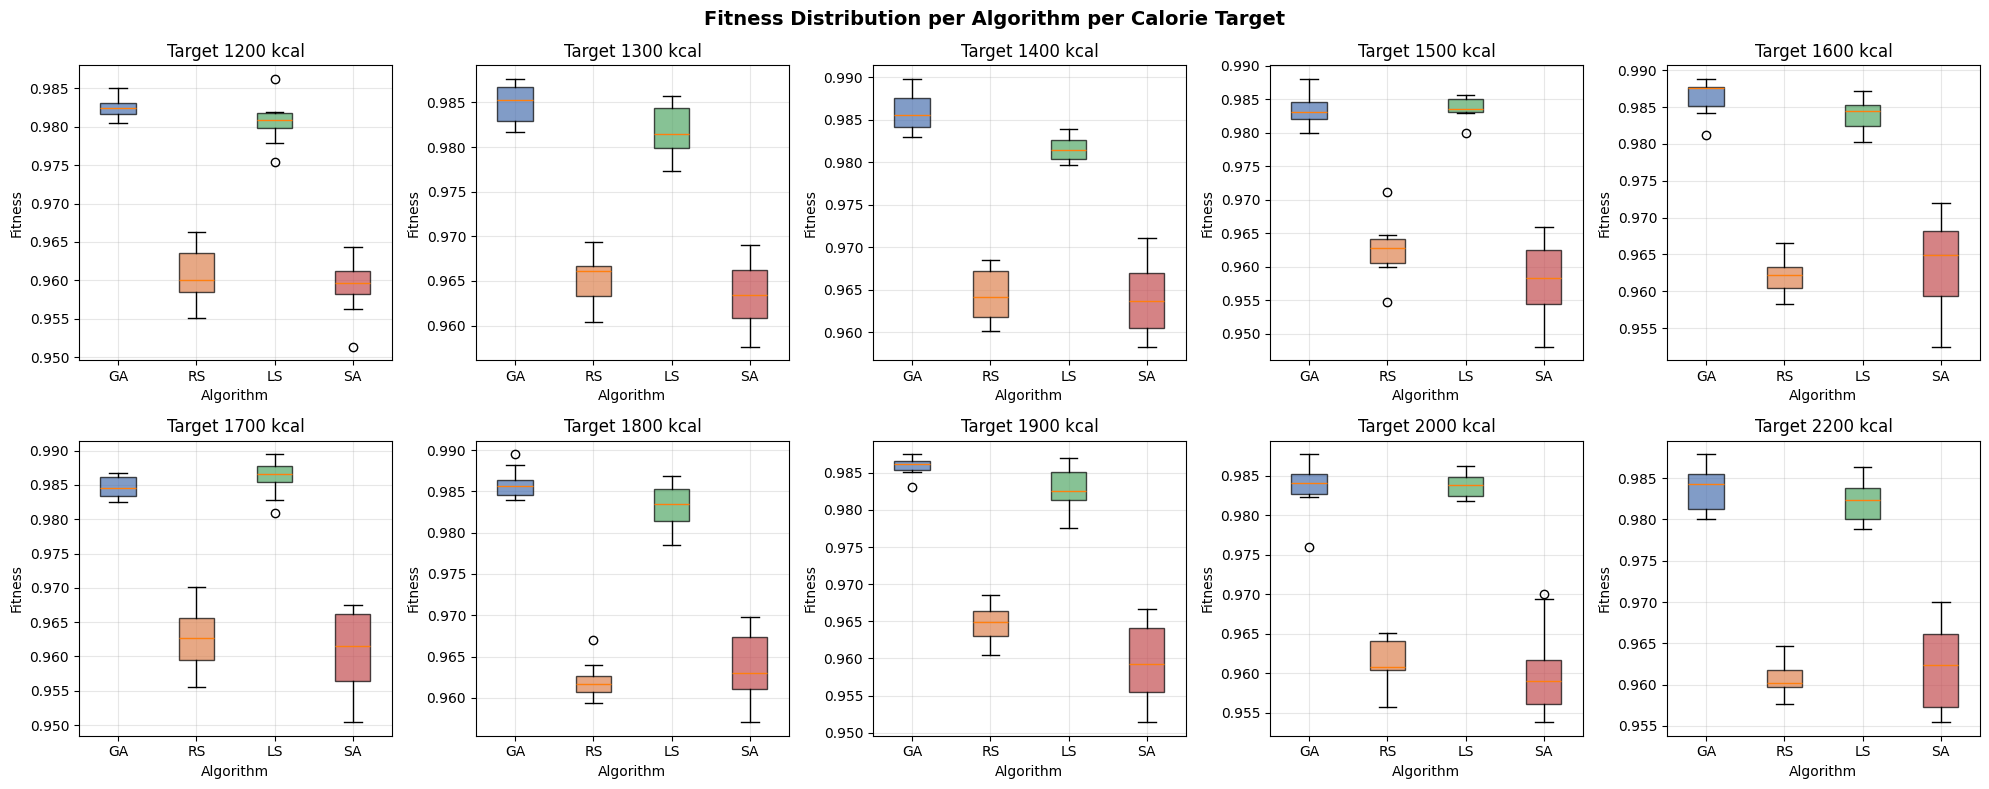

C:\Users\DSC\AppData\Local\Temp\ipykernel_19680\438582049.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19680\438582049.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19680\438582049.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19680\438582049.py:18: MatplotlibDeprecationWarning: The 'labels' p

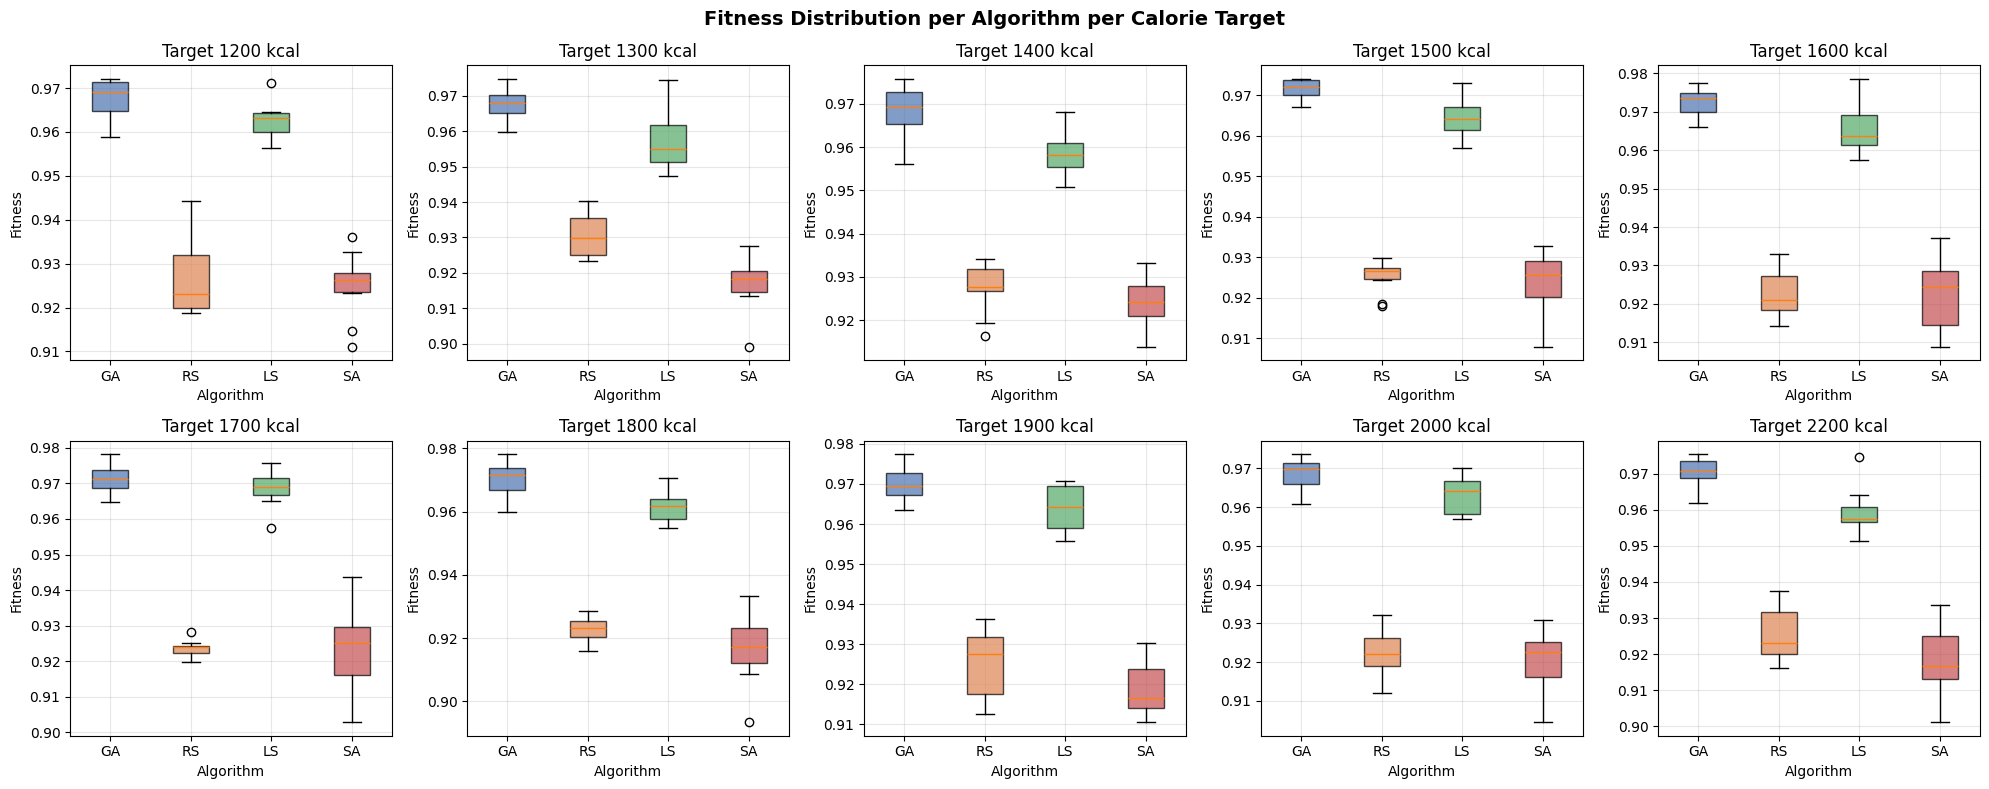

In [15]:
#box plot
import matplotlib.pyplot as plt
import numpy as np

for weights in weight_configs:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, target in enumerate(target_cals):
        ga = all_results[weights][target] ['ga']
        rs = all_results[weights][target]['rs']
        ls = all_results[weights][target]['ls']
        sa = all_results[weights][target]['sa']

        data = [ga, rs, ls, sa]
        labels = ['GA', 'RS', 'LS', 'SA']

        bp = axes[i].boxplot(data, labels=labels, patch_artist=True)

        colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        axes[i].set_title(f'Target {target} kcal')
        axes[i].set_xlabel('Algorithm')
        axes[i].set_ylabel('Fitness')
        axes[i].grid(True, alpha=0.3)

    plt.suptitle('Fitness Distribution per Algorithm per Calorie Target', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'boxplot_{weights}.png', dpi=300, bbox_inches='tight')
    plt.show()

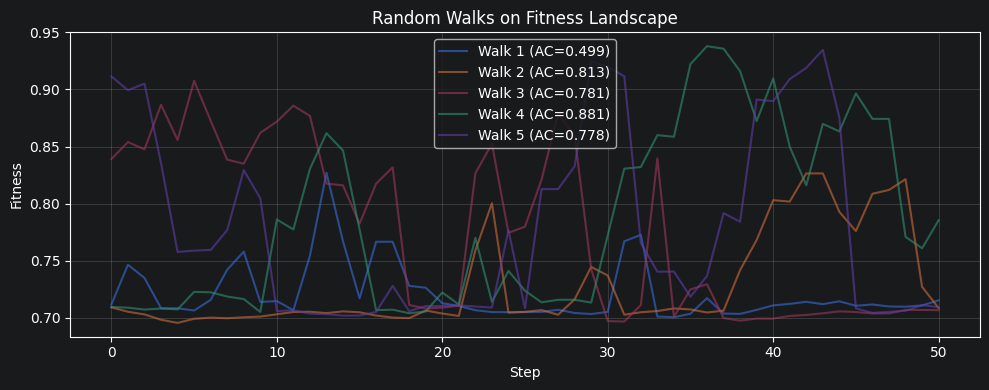

Mean Autocorrelation: 0.7503  (closer to 1 = smoother landscape)

Local Optima Analysis (50 random starts):
  Unique local optima found : 32
  Best  : 0.988600
  Worst : 0.979600
  Std   : 0.002030  (higher = more varied landscape)


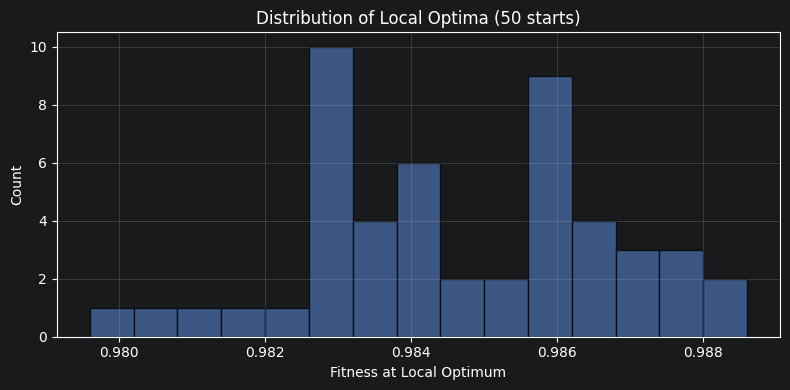

In [13]:
# Fitness Landscape Analysis
import matplotlib.pyplot as plt

N_WALKS = 5        # number of random walks for ruggedness
WALK_LENGTH = 50   # steps per walk
N_STARTS = 50      # starting points for local optima count

TARGET_KCAL = 1600  # fix one target for the analysis
WEIGHTS = (0.35, 0.35, 0.20, 0.10)

# --- 1. Ruggedness (Random Walk Autocorrelation) ---
def random_walk_autocorrelation(walk_length, lag=1):
    ind = create_individual()
    fitness_seq = [evaluate_meal_plan(ind)[0]]

    for _ in range(walk_length):
        ind, = mutate_meal_plan(ind)
        fitness_seq.append(evaluate_meal_plan(ind)[0])

    # Autocorrelation at given lag
    mean = np.mean(fitness_seq)
    diffs = np.array(fitness_seq) - mean
    ac = np.sum(diffs[:-lag] * diffs[lag:]) / np.sum(diffs ** 2)
    return fitness_seq, ac


all_ac = []
plt.figure(figsize=(10, 4))
for i in range(N_WALKS):
    seq, ac = random_walk_autocorrelation(WALK_LENGTH)
    all_ac.append(ac)
    plt.plot(seq, alpha=0.6, label=f'Walk {i+1} (AC={ac:.3f})')

plt.xlabel('Step')
plt.ylabel('Fitness')
plt.title('Random Walks on Fitness Landscape')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean Autocorrelation: {np.mean(all_ac):.4f}  (closer to 1 = smoother landscape)")


# --- 2. Local Optima Count ---
def find_local_optimum(toolbox, time_budget=2.0):
    ind = create_individual()
    ind.fitness.values = evaluate_meal_plan(ind)
    start = time.time()
    while (time.time() - start) < time_budget:
        neighbor, = mutate_meal_plan(toolbox.clone(ind))
        neighbor.fitness.values = evaluate_meal_plan(neighbor)
        if neighbor.fitness.values[0] > ind.fitness.values[0]:
            ind = neighbor
    return round(ind.fitness.values[0], 4)  # round to treat near-identical optima as the same


local_optima = [find_local_optimum(toolbox) for _ in range(N_STARTS)]
unique_optima = set(local_optima)

print(f"\nLocal Optima Analysis ({N_STARTS} random starts):")
print(f"  Unique local optima found : {len(unique_optima)}")
print(f"  Best  : {max(local_optima):.6f}")
print(f"  Worst : {min(local_optima):.6f}")
print(f"  Std   : {np.std(local_optima):.6f}  (higher = more varied landscape)")

plt.figure(figsize=(8, 4))
plt.hist(local_optima, bins=15, color='#4C72B0', alpha=0.7, edgecolor='black')
plt.xlabel('Fitness at Local Optimum')
plt.ylabel('Count')
plt.title(f'Distribution of Local Optima ({N_STARTS} starts)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

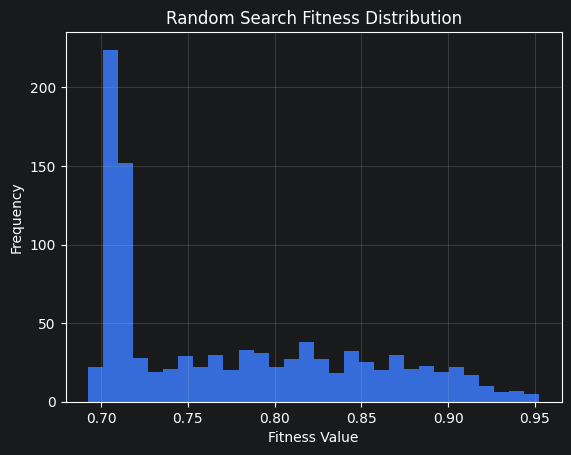

In [14]:
# Random Search Landscape Distribution

TARGET_KCAL = 1600
WEIGHTS = (0.35, 0.35, 0.20, 0.10)

random.seed(42)
np.random.seed(42)

fitness_values = []

for _ in range(1000):
    ind = create_individual()
    fitness = evaluate_meal_plan(ind)[0]
    fitness_values.append(fitness)

import matplotlib.pyplot as plt

plt.hist(fitness_values, bins=30)
plt.xlabel("Fitness Value")
plt.ylabel("Frequency")
plt.title("Random Search Fitness Distribution")
plt.grid(True, alpha=0.3)
plt.show()

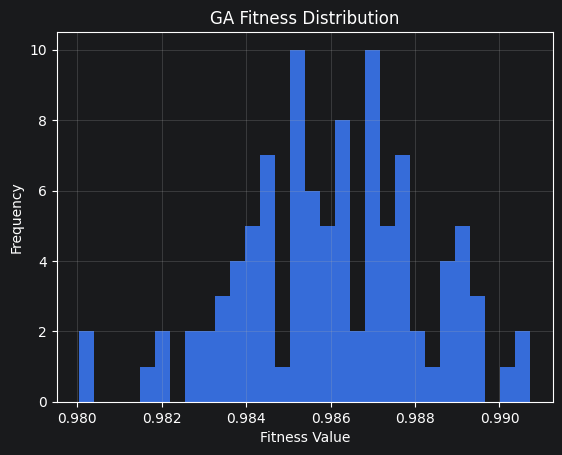

In [15]:
# GA Fitness Distribution

ga_fitness_values = []

NUM_RUNS = 100

for _ in range(NUM_RUNS):

    ga_fitness, _ = run_simulation(
        target_kcal=1600,
        pop_size=95,
        cxpb=0.55,
        mutpb=0.17,
        patience=50
    )

    ga_fitness_values.append(ga_fitness)

plt.hist(ga_fitness_values, bins=30)

plt.xlabel("Fitness Value")
plt.ylabel("Frequency")
plt.title("GA Fitness Distribution")

plt.grid(True, alpha=0.3)

plt.show()